# MVTec AD Data Exploration

This notebook validates the dataset manifest, examines dataset composition and leakage, reviews representative samples and preprocessing characteristics, compares normal train/test acquisition statistics, and analyzes defect size, shape, and location.

In [1]:
import cv2
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image, UnidentifiedImageError
from tqdm.auto import tqdm

tqdm.pandas()

/home/ali/projects/anomaly-detection/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.set_option('display.max_colwidth', 200)

In [3]:
data_path = Path.home() / 'projects/anomaly-detection/data/mvtec/'
# list(data_path.iterdir())

## 1. Build the dataset manifest

In [4]:
def get_image_metadata(path: str | Path) -> tuple[int | None, int | None, str | None]:
    """Return image width, height, and Pillow mode without loading pixel data.
    Uses PIL to efficiently obtain the image metadata by reading the image header only, without loading the whole image.
    
    Parameters
    ----------
    path : str or Path
        Path to the image file.
    
    Returns
    -------    
    tuple[int | None, int | None, str | None]
        Width, height, and Pillow image mode. Common modes include:  
        ``L``: 8-bit grayscale (0-255)  
        ``RGB``: 3-channels  
        ``RGBA``: RGB + alpha transparency, 4 channels  
        ``1``: binary black/white  
        ``P``: palette-based image  
        ``CMYK``: print-style cyan/magenta/yellow/black
    """
    try:
        with Image.open(path) as img:
            width, height = img.size
            mode = img.mode
        return width, height, mode
    except (UnidentifiedImageError, OSError) as e:
        print(f"Could not read image metadata for {path}:\n{e}")
        return None, None, None

In [5]:
def build_mvtec_manifest(root: str | Path) -> pd.DataFrame:
    root = Path(root)
    
    image_extensions = {".png", ".jpg", ".jpeg", ".bmp"}
    rows = []
    unhandled_files = []

    for product_dir in root.iterdir():
        if not product_dir.is_dir():
            continue

        product = product_dir.name

        # train and test images
        for split in ["train", "test"]:
            split_dir = product_dir / split
            if not split_dir.exists():
                continue

            for defect_dir in split_dir.iterdir():
                if not defect_dir.is_dir():
                    continue

                defect_type = defect_dir.name

                for image_path in defect_dir.iterdir():
                    if image_path.suffix.lower() not in image_extensions:
                        unhandled_files.append(image_path)
                        continue
                    
                    width, height, mode = get_image_metadata(image_path)
                    
                    image_id = image_path.stem
                    file_size_bytes = image_path.stat().st_size
                    mask_path = product_dir / "ground_truth" / defect_type / f"{image_id}_mask.png"

                    rows.append({
                        "path": image_path,
                        "filename": image_path.name,
                        "image_id": image_id,
                        "product": product,
                        "split": split,
                        "defect_type": defect_type,
                        "kind": "image",
                        "is_good": defect_type == "good",
                        "is_defect": split == "test" and defect_type != "good",
                        "has_mask": mask_path.exists(),
                        "mask_path": str(mask_path) if mask_path.exists() else None,
                        "width": width,
                        "height": height,
                        "mode": mode,
                        "aspect_ratio": width / height if width and height else None,
                        "megapixels": width * height / 1_000_000 if width and height else None,
                        "file_size_bytes": file_size_bytes,
                        "file_size_kb": round(file_size_bytes / 1024, 2),
                        "suffix": image_path.suffix.lower(),
                    })

        # ground truth masks
        gt_dir = product_dir / "ground_truth"
        if gt_dir.exists():
            for defect_dir in gt_dir.iterdir():
                if not defect_dir.is_dir():
                    continue

                defect_type = defect_dir.name

                for mask_path in defect_dir.iterdir():
                    if mask_path.suffix.lower() not in image_extensions:
                        unhandled_files.append(mask_path)
                        continue

                    width, height, mode = get_image_metadata(mask_path)

                    image_id = mask_path.stem.removesuffix("_mask")
                    file_size_bytes = mask_path.stat().st_size

                    rows.append({
                        "path": mask_path,
                        "filename": mask_path.name,
                        "image_id": image_id,
                        "product": product,
                        "split": "ground_truth",
                        "defect_type": defect_type,
                        "kind": "mask",
                        "is_good": False,
                        "is_defect": False,
                        "has_mask": False,
                        "mask_path": None,
                        "width": width,
                        "height": height,
                        "mode": mode,
                        "aspect_ratio": width / height if width and height else None,
                        "megapixels": width * height / 1_000_000 if width and height else None,
                        "file_size_bytes": file_size_bytes,
                        "file_size_kb": round(file_size_bytes / 1024, 2),
                        "suffix": mask_path.suffix.lower(),
                    })

    df = pd.DataFrame(rows)

    if not df.empty:
        df["path"] = df["path"].astype(str)
        
    if unhandled_files:
        print(f'There were {len(unhandled_files)} files not taken into consideration, e.g.: {unhandled_files[:3]}')

    return df

In [6]:
df = build_mvtec_manifest(data_path)

display(df.head())
display(
    df.groupby(['kind', 'split'], dropna=False)
    .size()
    .rename('file_count')
    .to_frame()
)

,path,filename,image_id,product,split,defect_type,kind,is_good,is_defect,has_mask,mask_path,width,height,mode,aspect_ratio,megapixels,file_size_bytes,file_size_kb,suffix
0,/home/ali/projects/anomaly-detection/data/mvtec/capsule/train/good/151.png,151.png,151,capsule,train,good,image,True,False,False,NaN,1000,1000,RGB,1.0,1.0,1115933,1089.78,.png
1,/home/ali/projects/anomaly-detection/data/mvtec/capsule/train/good/209.png,209.png,209,capsule,train,good,image,True,False,False,NaN,1000,1000,RGB,1.0,1.0,1162560,1135.31,.png
2,/home/ali/projects/anomaly-detection/data/mvtec/capsule/train/good/022.png,022.png,022,capsule,train,good,image,True,False,False,NaN,1000,1000,RGB,1.0,1.0,1161002,1133.79,.png
3,/home/ali/projects/anomaly-detection/data/mvtec/capsule/train/good/208.png,208.png,208,capsule,train,good,image,True,False,False,NaN,1000,1000,RGB,1.0,1.0,1150679,1123.71,.png
4,/home/ali/projects/anomaly-detection/data/mvtec/capsule/train/good/013.png,013.png,013,capsule,train,good,image,True,False,False,NaN,1000,1000,RGB,1.0,1.0,1146994,1120.11,.png


file_count
kind  split                   
image test                1725
      train               3629
mask  ground_truth        1258

In [7]:
image_df = df[df['kind'].eq('image')].copy()
mask_df = df[df['kind'].eq('mask')].copy()

image_df['subset'] = np.select(
    [
        image_df['split'].eq('train') & image_df['is_good'],
        image_df['split'].eq('test') & image_df['is_good'],
        image_df['split'].eq('test') & image_df['is_defect'],
    ],
    ['train_good', 'test_good', 'test_defect'],
    default='other',
)

### Manifest integrity

Validate the structural assumptions required by all later analyses using only the loaded manifest metadata.

In [8]:
defective_images = image_df[image_df['is_defect']]
good_images = image_df[image_df['is_good']]
pairing_columns = ['product', 'defect_type', 'image_id']

paired_defects = defective_images.merge(
    mask_df,
    on=pairing_columns,
    how='outer',
    suffixes=('_image', '_mask'),
    indicator=True,
    validate='one_to_one',
)
paired_rows = paired_defects['_merge'].eq('both')
dimensions_match = (
    paired_defects.loc[paired_rows, 'width_image'].eq(
        paired_defects.loc[paired_rows, 'width_mask']
    )
    & paired_defects.loc[paired_rows, 'height_image'].eq(
        paired_defects.loc[paired_rows, 'height_mask']
    )
)

manifest_checks = pd.Series({
    'all files have image metadata': df[['width', 'height', 'mode']].notna().all(axis=1).all(),
    'every defective test image has a mask': defective_images['has_mask'].all(),
    'good images have no masks': not good_images['has_mask'].any(),
    'image-mask pairing is complete': paired_rows.all(),
    'paired image-mask dimensions match': dimensions_match.all(),
    'all masks use grayscale mode': mask_df['mode'].eq('L').all(),
}, name='passed')

display(manifest_checks)
assert manifest_checks.all(), 'One or more manifest integrity checks failed.' 

all files have image metadata            True
every defective test image has a mask    True
good images have no masks                True
image-mask pairing is complete           True
paired image-mask dimensions match       True
all masks use grayscale mode             True
Name: passed, dtype: bool

## 2. Dataset composition

Quantify the one-class training setup, product imbalance, and the defect types represented in the test set.

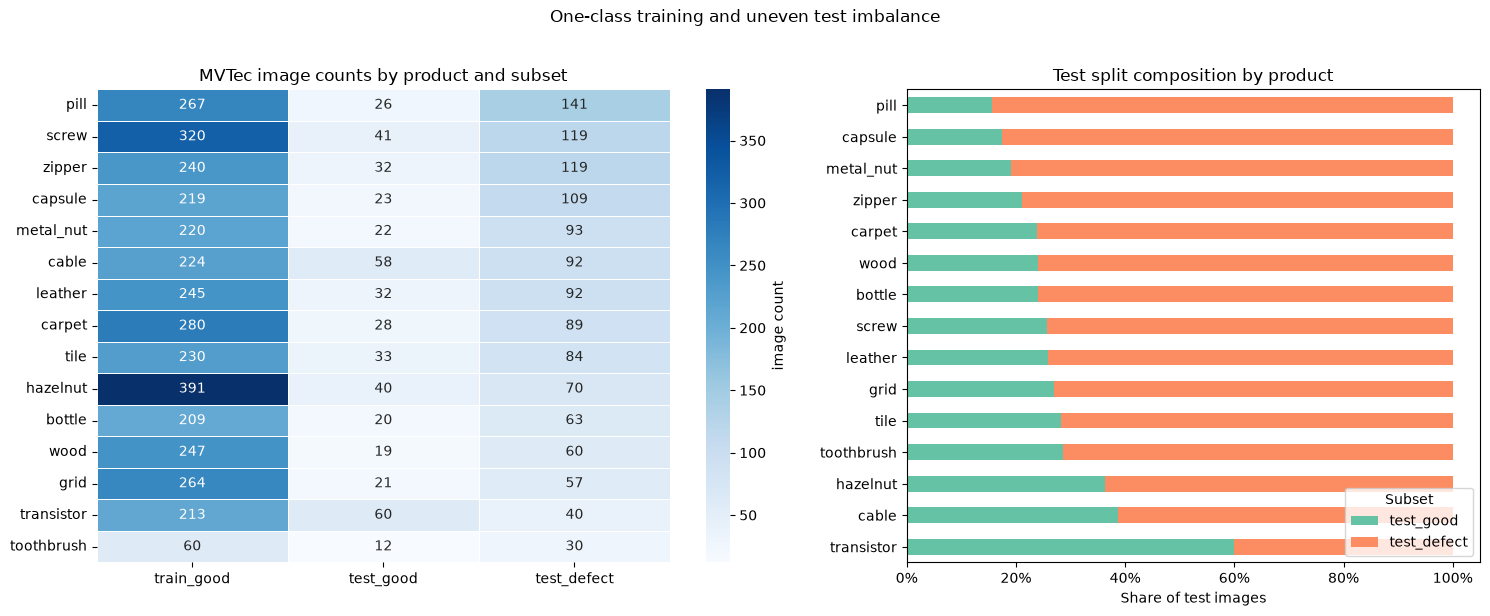

In [9]:
count_table = (
    image_df.groupby(['product', 'subset'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['train_good', 'test_good', 'test_defect'], fill_value=0)
    .sort_values('test_defect', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), width_ratios=[1.25, 1])

sns.heatmap(
    count_table,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    cbar_kws={'label': 'image count'},
    ax=axes[0],
)
axes[0].set_title('MVTec image counts by product and subset')
axes[0].set_xlabel('')
axes[0].set_ylabel('')

test_mix = count_table[['test_good', 'test_defect']]
test_mix_pct = test_mix.div(test_mix.sum(axis=1), axis=0).sort_values('test_defect')
test_mix_pct.plot(kind='barh', stacked=True, ax=axes[1], color=['#66c2a5', '#fc8d62'])
axes[1].set_title('Test split composition by product')
axes[1].set_xlabel('Share of test images')
axes[1].set_ylabel('')
axes[1].legend(title='Subset', loc='lower right')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.0%}'))

fig.suptitle('One-class training and uneven test imbalance', y=1.02)
fig.tight_layout()
plt.show()

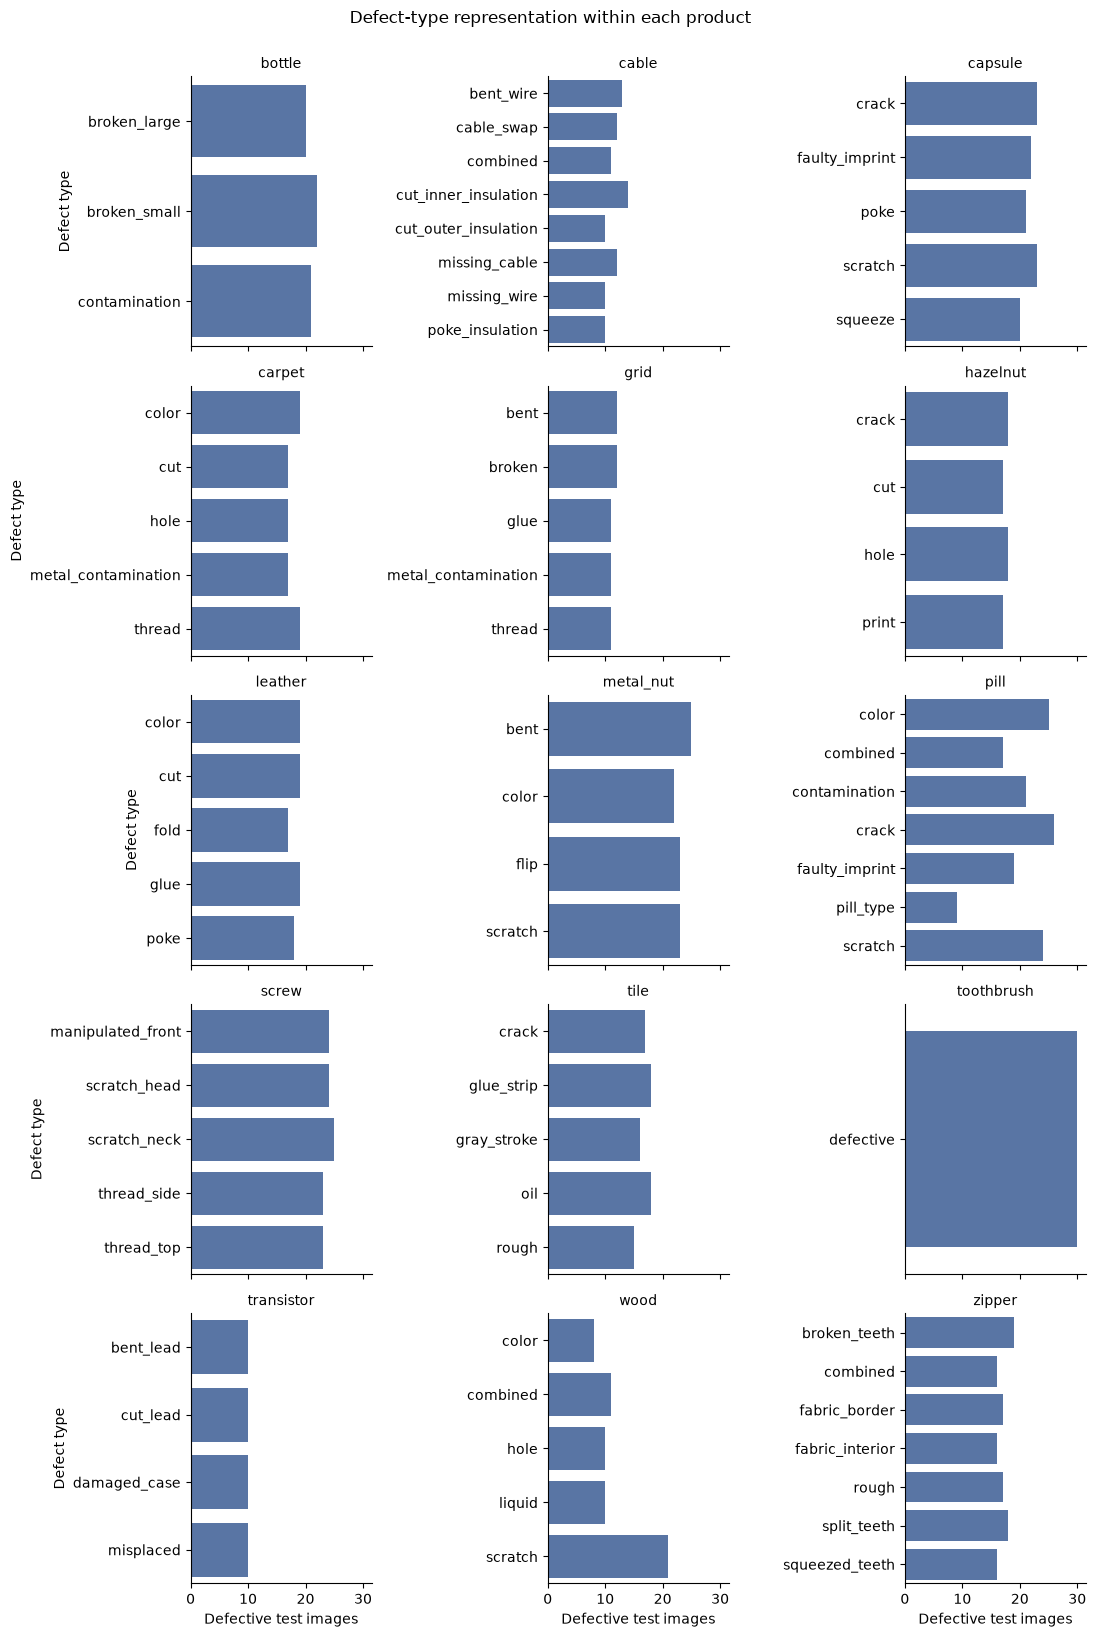

In [10]:
defect_counts = (
    image_df[image_df['is_defect']]
    .groupby(['product', 'defect_type'])
    .size()
    .rename('image_count')
    .reset_index()
)

g = sns.catplot(
    data=defect_counts,
    x='image_count',
    y='defect_type',
    col='product',
    col_wrap=3,
    kind='bar',
    sharey=False,
    height=3.2,
    aspect=1.15,
    color='#4c72b0',
)
g.set_axis_labels('Defective test images', 'Defect type')
g.set_titles('{col_name}')
g.fig.suptitle('Defect-type representation within each product', y=1.02)
plt.show()

## 3. Exact duplicates and train/test leakage

SHA-256 hashes identify byte-for-byte duplicate images. The cached hashes avoid rereading every file on later notebook runs. Set the flag to `True` after changing the dataset.

In [ ]:
def calculate_sha256(path: str | Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with Path(path).open('rb') as file:
        while chunk := file.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()

REBUILD_FILE_HASHES = False
hash_cache_path = data_path.parent / 'cache' / 'image_sha256.parquet'
hash_cache_path.parent.mkdir(parents=True, exist_ok=True)

if REBUILD_FILE_HASHES or not hash_cache_path.exists():
    image_hashes = image_df[['path']].copy()
    image_hashes['sha256'] = image_hashes['path'].progress_apply(calculate_sha256)
    image_hashes.to_parquet(hash_cache_path, engine='pyarrow', index=False)
    print(f'Saved image hashes to {hash_cache_path}')
else:
    image_hashes = pd.read_parquet(hash_cache_path, engine='pyarrow')
    print(f'Loaded image hashes from {hash_cache_path}')

image_df = (
    image_df.drop(columns='sha256', errors='ignore')
    .merge(image_hashes, on='path', how='left', validate='one_to_one')
)
assert image_df['sha256'].notna().all(), 'Some images are missing hashes.' 

In [ ]:
duplicate_images = image_df[image_df.duplicated('sha256', keep=False)].copy()

duplicate_groups = (
    duplicate_images.groupby('sha256')
    .agg(
        file_count=('path', 'size'),
        products=('product', lambda values: sorted(set(values))),
        splits=('split', lambda values: sorted(set(values))),
        subsets=('subset', lambda values: sorted(set(values))),
        paths=('path', list),
    )
    .sort_values('file_count', ascending=False)
)

if duplicate_groups.empty:
    print('No exact duplicate images found.')
else:
    cross_split_duplicates = duplicate_groups[
        duplicate_groups['splits'].apply(len).gt(1)
    ]
    print(f'Exact duplicate groups: {len(duplicate_groups)}')
    print(f'Groups crossing train/test: {len(cross_split_duplicates)}')
    display(duplicate_groups)
    assert cross_split_duplicates.empty, 'Exact train/test leakage detected.' 

## 4. Representative images

Representative normal and anomalous samples provide visual context for the aggregate statistics that follow.

In [ ]:
def load_image_for_display(path: str | Path, mode: str) -> np.ndarray:
    if mode == 'RGB':
        image = cv2.imread(str(path), cv2.IMREAD_COLOR)
        if image is None:
            raise ValueError(f'Could not decode {path}')
        return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    if mode == 'L':
        image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f'Could not decode {path}')
        return image
    raise ValueError(f'Unsupported image mode: {mode}')

normal_samples = (
    image_df[image_df['subset'].eq('train_good')]
    .groupby('product', group_keys=False)
    .sample(n=1, random_state=12)
    .sort_values('product')
)

fig, axes = plt.subplots(3, 5, figsize=(15, 10))
for ax, (_, row) in zip(axes.flat, normal_samples.iterrows(), strict=True):
    image = load_image_for_display(row['path'], row['mode'])
    ax.imshow(image, cmap='gray' if row['mode'] == 'L' else None)
    ax.set_title(row['product'])
    ax.axis('off')
fig.suptitle('Representative normal training image per product')
plt.tight_layout()
plt.show()

In [ ]:
defect_samples = (
    image_df[image_df['is_defect']]
    .groupby('product', group_keys=False)
    .sample(n=1, random_state=12)
    .sort_values('product')
)

fig, axes = plt.subplots(3, 5, figsize=(15, 10))
for ax, (_, row) in zip(axes.flat, defect_samples.iterrows(), strict=True):
    image = load_image_for_display(row['path'], row['mode'])
    mask = cv2.imread(str(row['mask_path']), cv2.IMREAD_GRAYSCALE)
    ax.imshow(image, cmap='gray' if row['mode'] == 'L' else None)
    ax.imshow(mask, cmap='Reds', alpha=0.35, vmin=0, vmax=255)
    ax.set_title(f"{row['product']}\n{row['defect_type']}")
    ax.axis('off')
fig.suptitle('Representative defective test image with mask overlay per product')
plt.tight_layout()
plt.show()

## 5. Image modes and dimensions

Review format and resolution differences that affect resizing, channel handling, and model preprocessing.

In [ ]:
mode_by_product = (
    image_df.groupby(['product', 'mode'])
    .size()
    .unstack(fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
image_df['mode'].value_counts().plot(kind='bar', ax=axes[0], color=['#4c72b0', '#dd8452'])
axes[0].set_title('Image color modes')
axes[0].set_xlabel('Mode')
axes[0].set_ylabel('Image count')
axes[0].tick_params(axis='x', rotation=0)

mode_by_product.plot(kind='bar', stacked=True, ax=axes[1], cmap='viridis')
axes[1].set_title('Color modes by product')
axes[1].set_xlabel('Product')
axes[1].set_ylabel('Image count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Mode')

for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.histplot(image_df['width'], bins=30, ax=axes[0], color='skyblue')
axes[0].set_title('Image widths')
axes[0].set_xlabel('Width (pixels)')

sns.histplot(image_df['height'], bins=30, ax=axes[1], color='lightcoral')
axes[1].set_title('Image heights')
axes[1].set_xlabel('Height (pixels)')

sns.histplot(image_df['aspect_ratio'], bins=30, ax=axes[2], color='lightgreen')
axes[2].set_title('Image aspect ratios')
axes[2].set_xlabel('Width / height')

for ax in axes:
    ax.set_ylabel('Image count')
plt.tight_layout()
plt.show()

## 6. Normal train/test pixel statistics

Brightness and contrast are compared within products to identify acquisition shift. These global statistics are quality and domain-shift indicators, not direct detectors of localized defects.

In [ ]:
def calculate_pixel_statistics(image_path: str | Path, mode: str) -> pd.Series:
    """Calculate comparable luminance statistics and optional RGB-channel statistics."""
    feature_names = [
        'intensity_mean', 'intensity_std', 'intensity_p05',
        'intensity_median', 'intensity_p95', 'intensity_range_p90',
        'red_mean', 'green_mean', 'blue_mean',
        'red_std', 'green_std', 'blue_std',
    ]

    try:
        if mode == 'RGB':
            bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
            if bgr is None:
                raise ValueError('OpenCV could not decode the image')
            rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
            luminance = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
            channel_means = rgb.mean(axis=(0, 1))
            channel_stds = rgb.std(axis=(0, 1))
        elif mode == 'L':
            luminance = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
            if luminance is None:
                raise ValueError('OpenCV could not decode the image')
            channel_means = [np.nan] * 3
            channel_stds = [np.nan] * 3
        else:
            raise ValueError(f'Unsupported image mode: {mode}')

        p05, median, p95 = np.percentile(luminance, [5, 50, 95])
        values = [
            luminance.mean(), luminance.std(), p05, median, p95, p95 - p05,
            *channel_means, *channel_stds,
        ]
        return pd.Series(dict(zip(feature_names, values, strict=True)))
    except (OSError, ValueError) as error:
        print(f'Could not calculate pixel statistics for {image_path}: {error}')
        return pd.Series({name: np.nan for name in feature_names})

In [ ]:
REBUILD_PIXEL_FEATURES = False

pixel_feature_columns = [
    'intensity_mean', 'intensity_std', 'intensity_p05',
    'intensity_median', 'intensity_p95', 'intensity_range_p90',
    'red_mean', 'green_mean', 'blue_mean',
    'red_std', 'green_std', 'blue_std',
]
pixel_cache_path = data_path.parent / 'cache' / 'image_pixel_features.parquet'
pixel_cache_path.parent.mkdir(parents=True, exist_ok=True)

if REBUILD_PIXEL_FEATURES or not pixel_cache_path.exists():
    print('Calculating pixel statistics for all images...')
    calculated_features = image_df.progress_apply(
        lambda row: calculate_pixel_statistics(row['path'], row['mode']),
        axis=1,
    )
    pixel_features = pd.concat(
        [image_df[['path']].reset_index(drop=True),
         calculated_features.reset_index(drop=True)],
        axis=1,
    )
    pixel_features.to_parquet(pixel_cache_path, engine='pyarrow', index=False)
    print(f'Saved pixel features to {pixel_cache_path}')
else:
    pixel_features = pd.read_parquet(pixel_cache_path, engine='pyarrow')
    print(f'Loaded pixel features from {pixel_cache_path}')

image_df = (
    image_df.drop(columns=pixel_feature_columns, errors='ignore')
    .merge(
        pixel_features[['path', *pixel_feature_columns]],
        on='path',
        how='left',
        validate='one_to_one',
    )
)

assert image_df[pixel_feature_columns].notna().any(axis=1).all(), (
    'Some images did not produce pixel statistics.'
)

In [ ]:
normal_images = image_df[image_df['subset'].isin(['train_good', 'test_good'])].copy()

fig, axes = plt.subplots(1, 2, figsize=(17, 7), sharey=True)

sns.boxplot(
    data=normal_images,
    y='product',
    x='intensity_mean',
    hue='subset',
    ax=axes[0],
    showfliers=False,
)
axes[0].set_title('Normal-image brightness: train versus test')
axes[0].set_xlabel('Mean luminance (0-255)')
axes[0].set_ylabel('Product')

sns.boxplot(
    data=normal_images,
    y='product',
    x='intensity_std',
    hue='subset',
    ax=axes[1],
    showfliers=False,
)
axes[1].set_title('Normal-image contrast: train versus test')
axes[1].set_xlabel('Luminance standard deviation')
axes[1].set_ylabel('')

for ax in axes:
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.legend(title='Subset', loc='best')

fig.suptitle('Potential acquisition shift within each product', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
normal_intensity_summary = (
    normal_images.groupby(['product', 'subset'], observed=True)
    .agg(
        image_count=('path', 'size'),
        mean_luminance=('intensity_mean', 'mean'),
        mean_contrast=('intensity_std', 'mean'),
        mean_p90_range=('intensity_range_p90', 'mean'),
    )
    .unstack('subset')
)

for metric in ['mean_luminance', 'mean_contrast', 'mean_p90_range']:
    normal_intensity_summary[(metric, 'test_minus_train')] = (
        normal_intensity_summary[(metric, 'test_good')]
        - normal_intensity_summary[(metric, 'train_good')]
    )

normal_intensity_summary = normal_intensity_summary.sort_values(
    ('mean_luminance', 'test_minus_train'),
    key=abs,
    ascending=False,
)
display(normal_intensity_summary.round(2))

## 7. Mask size, shape, and location

Decode every mask once to calculate area, bounding-box, connected-component, border-contact, and centroid features. The simple rebuild flag controls the Parquet cache.

In [ ]:
def calculate_mask_features(mask_path: str | Path) -> pd.Series:
    feature_names = [
        'defect_area_percentage',
        'bbox_width_norm', 'bbox_height_norm', 'bbox_area_percentage',
        'bbox_fill_ratio', 'connected_component_count', 'touches_border',
        'defect_centroid_x', 'defect_centroid_y',
    ]
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return pd.Series({name: np.nan for name in feature_names})

    binary = mask > 0
    rows, cols = np.where(binary)
    if len(rows) == 0:
        return pd.Series({name: np.nan for name in feature_names})

    height, width = mask.shape
    x_min, x_max = cols.min(), cols.max()
    y_min, y_max = rows.min(), rows.max()
    bbox_width = x_max - x_min + 1
    bbox_height = y_max - y_min + 1
    defect_pixels = binary.sum()
    _, component_labels = cv2.connectedComponents(binary.astype(np.uint8), connectivity=8)
    component_count = component_labels.max()
    touches_border = (
        binary[0, :].any() or binary[-1, :].any()
        or binary[:, 0].any() or binary[:, -1].any()
    )

    return pd.Series({
        'defect_area_percentage': 100 * defect_pixels / (width * height),
        'bbox_width_norm': bbox_width / width,
        'bbox_height_norm': bbox_height / height,
        'bbox_area_percentage': 100 * bbox_width * bbox_height / (width * height),
        'bbox_fill_ratio': defect_pixels / (bbox_width * bbox_height),
        'connected_component_count': component_count,
        'touches_border': touches_border,
        'defect_centroid_x': cols.mean(),
        'defect_centroid_y': rows.mean(),
    })

REBUILD_MASK_FEATURES = False
mask_feature_columns = [
    'defect_area_percentage',
    'bbox_width_norm', 'bbox_height_norm', 'bbox_area_percentage',
    'bbox_fill_ratio', 'connected_component_count', 'touches_border',
    'defect_centroid_x', 'defect_centroid_y',
]
mask_cache_path = data_path.parent / 'cache' / 'mask_features.parquet'
mask_cache_path.parent.mkdir(parents=True, exist_ok=True)

if REBUILD_MASK_FEATURES or not mask_cache_path.exists():
    calculated_mask_features = mask_df['path'].progress_apply(calculate_mask_features)
    mask_features = pd.concat(
        [mask_df[['path']].reset_index(drop=True), calculated_mask_features.reset_index(drop=True)],
        axis=1,
    )
    mask_features.to_parquet(mask_cache_path, engine='pyarrow', index=False)
    print(f'Saved mask features to {mask_cache_path}')
else:
    mask_features = pd.read_parquet(mask_cache_path, engine='pyarrow')
    print(f'Loaded mask features from {mask_cache_path}')

mask_df = (
    mask_df.drop(columns=mask_feature_columns, errors='ignore')
    .merge(mask_features[['path', *mask_feature_columns]], on='path', how='left', validate='one_to_one')
)
assert mask_df[mask_feature_columns].notna().all(axis=1).all(), (
    'Some masks did not produce valid features.'
)

### Defect area by product and defect type

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

sns.histplot(mask_df['defect_area_percentage'], bins=50, kde=True, ax=axes[0], color='purple')
axes[0].set_title('Overall defect-area distribution')
axes[0].set_xlabel('Defect area (% of image)')
axes[0].set_ylabel('Mask count')

sns.boxplot(
    data=mask_df,
    y='product',
    x='defect_area_percentage',
    showfliers=False,
    ax=axes[1],
)
axes[1].set_xscale('log')
axes[1].set_title('Defect area by product')
axes[1].set_xlabel('Defect area (% of image, log scale)')
axes[1].set_ylabel('Product')
axes[1].grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()
display(mask_df['defect_area_percentage'].describe().to_frame())

In [ ]:
g = sns.catplot(
    data=mask_df,
    x='defect_area_percentage',
    y='defect_type',
    col='product',
    col_wrap=3,
    kind='box',
    sharey=False,
    showfliers=False,
    height=3.2,
    aspect=1.15,
)
for ax in g.axes.flat:
    ax.set_xscale('log')
    ax.grid(axis='x', linestyle='--', alpha=0.35)
g.set_axis_labels('Defect area (% of image, log scale)', 'Defect type')
g.set_titles('{col_name}')
g.fig.suptitle('Defect-size variation by defect type', y=1.02)
plt.show()

### Smallest and largest defects

Overlay examples from both tails of the mask-area distribution to make the numerical scale visually interpretable.

In [ ]:
extreme_masks = pd.concat([
    mask_df.nsmallest(5, 'defect_area_percentage').assign(area_group='smallest'),
    mask_df.nlargest(5, 'defect_area_percentage').assign(area_group='largest'),
])[
    ['product', 'defect_type', 'image_id', 'path', 'defect_area_percentage', 'area_group']
]
extreme_examples = extreme_masks.merge(
    image_df.loc[
        image_df['is_defect'],
        ['product', 'defect_type', 'image_id', 'path', 'mode'],
    ],
    on=['product', 'defect_type', 'image_id'],
    suffixes=('_mask', '_image'),
    validate='one_to_one',
)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, (_, row) in zip(axes.flat, extreme_examples.iterrows(), strict=True):
    image = load_image_for_display(row['path_image'], row['mode'])
    mask = cv2.imread(str(row['path_mask']), cv2.IMREAD_GRAYSCALE)
    ax.imshow(image, cmap='gray' if row['mode'] == 'L' else None)
    ax.imshow(mask, cmap='Reds', alpha=0.4, vmin=0, vmax=255)
    ax.set_title(
        f"{row['area_group']}: {row['defect_area_percentage']:.3f}%\n"
        f"{row['product']} — {row['defect_type']}"
    )
    ax.axis('off')
plt.tight_layout()
plt.show()

### Defect shape and complexity

In [ ]:
border_rate = (
    mask_df.groupby('product')['touches_border']
    .mean()
    .sort_values()
)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(data=mask_df, y='product', x='bbox_fill_ratio', showfliers=False, ax=axes[0, 0])
axes[0, 0].set_title('How densely defects fill their bounding boxes')
axes[0, 0].set_xlabel('Mask pixels / bounding-box pixels')

sns.boxplot(data=mask_df, y='product', x='bbox_area_percentage', showfliers=False, ax=axes[0, 1])
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('Defect bounding-box area')
axes[0, 1].set_xlabel('Bounding-box area (% of image, log scale)')

sns.boxplot(data=mask_df, y='product', x='connected_component_count', showfliers=False, ax=axes[1, 0])
axes[1, 0].set_title('Disconnected defect regions')
axes[1, 0].set_xlabel('Connected-component count')

border_rate.plot(kind='barh', ax=axes[1, 1], color='#dd8452')
axes[1, 1].set_title('Defects touching an image border')
axes[1, 1].set_xlabel('Share of masks')
axes[1, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.0%}'))

for ax in axes.flat:
    ax.set_ylabel('Product')
    ax.grid(axis='x', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

### Normalized defect location

In [ ]:
mask_df['centroid_x_norm'] = mask_df['defect_centroid_x'] / mask_df['width']
mask_df['centroid_y_norm'] = mask_df['defect_centroid_y'] / mask_df['height']

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

sns.boxplot(data=mask_df, y='product', x='centroid_x_norm', ax=axes[0])
axes[0].set_title('Horizontal defect location by product')
axes[0].set_xlabel('Normalized position: left (0) to right (1)')
axes[0].set_ylabel('Product')

sns.boxplot(data=mask_df, y='product', x='centroid_y_norm', ax=axes[1])
axes[1].set_title('Vertical defect location by product')
axes[1].set_xlabel('Normalized position: top (0) to bottom (1)')
axes[1].set_ylabel('')

for ax in axes:
    ax.axvline(0.5, color='red', linestyle='--', alpha=0.5)
    ax.set_xlim(0, 1)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

fig.suptitle('Normalized defect centroid locations by product', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
g = sns.FacetGrid(mask_df, col='product', col_wrap=5, height=3, aspect=1)
g.map_dataframe(
    sns.scatterplot,
    x='centroid_x_norm',
    y='centroid_y_norm',
    hue='defect_type',
    s=22,
    alpha=0.65,
    legend=False,
)

for ax in g.axes.flat:
    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(ax.get_title().replace('product = ', ''))

g.set_axis_labels('Normalized X', 'Normalized Y')
g.fig.suptitle('Defect centroids by product and defect type', y=1.02)
plt.tight_layout()
plt.show()

## 8. Conclusions and modeling implications

- **Dataset structure:** Training images are normal-only, while test composition and defect-type counts vary by product. Model selection and evaluation must therefore report per-product results rather than only a global average.
- **Integrity and leakage:** The manifest checks establish complete one-to-one image–mask pairing and matching dimensions. The hash analysis explicitly reports any exact duplicates or train/test leakage.
- **Preprocessing:** Products differ in image mode and resolution, so channel handling and resizing must be defined explicitly. Product-aware preprocessing or separate product models are appropriate baselines.
- **Normal-domain shift:** Brightness and contrast comparisons between `train_good` and `test_good` reveal whether acquisition differences could be mistaken for anomalies. These statistics should be interpreted within each product.
- **Defect difficulty:** Defect area, bounding-box fill, connected components, border contact, and spatial location describe complementary aspects of difficulty. Small, thin, fragmented, or border-touching defects may require higher-resolution and more spatially sensitive models.
- **Evaluation:** Use both image-level and pixel-level metrics, report them per product and defect type, and inspect performance as a function of defect size.

The next stage should establish preprocessing and baseline anomaly-detection models. Learned feature embeddings and dimensionality reduction belong there rather than in this initial structural EDA.